In [1]:
from utils import *
%matplotlib inline
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec,GridSpecFromSubplotSpec
from matplotlib.ticker import MultipleLocator

Running calculations for (a) MoS$_2$/MoS$_2$
50 trajectories used..
50 trajectories used..
50 trajectories used..
Running calculations for (b) WS$_2$/WS$_2$
50 trajectories used..
50 trajectories used..
50 trajectories used..
Running calculations for (c) MoS$_2$/WS$_2$
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
Running calculations for (d) MoSe$_2$/MoSe$_2$
50 trajectories used..
50 trajectories used..
50 trajectories used..
Running calculations for (e) WSe$_2$/WSe$_2$
50 trajectories used..
50 trajectories used..
49 trajectories used..
Running calculations for (f) MoSe$_2$/WSe$_2$
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..


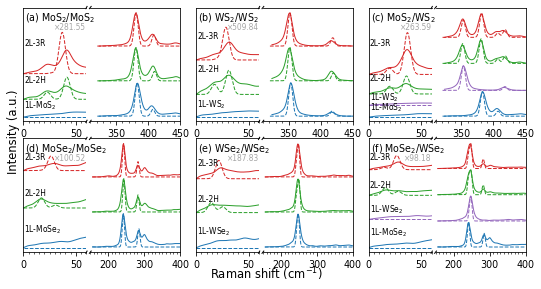

In [5]:
def plot_raman_aligned(axs, x1, x2, y,low_range,high_range, index):
    
    # --- PARAMETERS ---
    temp = 300
    timesteps = 10000
    nsteps = 10000
    std = 3
    interval = 1
    freq_lim = (0,1000)
    nruns = 50
    xspace = np.linspace(0,1000,10000)
    xspace_static = np.linspace(0, 500, 5000)
    polarisation = 'unpolarised'


    mdict = {0: 'Mo', 1: 'W'}
    chdict = {0: 'S', 1: 'Se'}
    
    label = rf"({chr(ord('a') + index)}) {mdict[x1]}{chdict[y]}$_2$/{mdict[x2]}{chdict[y]}$_2$" 
    print(rf'Running calculations for {label}')

    # --- MONOLAYER 1 ---
    foldername = 'monolayer_md_data/'  ## Folder containing Monolayer trajectories
    freqs, intens_mono1 = calculate_average_spectra(
        foldername, x1, y, temp, timesteps, nsteps,
        nruns, interval, xspace, freq_lim, std, derivative=False,
        polarisation=polarisation,reduced=True
    )
    intens_mono1 /= max(intens_mono1)

    npzfile = np.load(f'first_order_raman/{mdict[x1]}SSe_x{x1:0.3f}y{y:0.3f}_config_0.npz')
    freqs_static, intens_static_mono1 = npzfile['freqs'], npzfile['intensities']
    freqs_static, intens_static_mono1 = get_spectra_curve(xspace_static, intens_static_mono1, freqs_static, std)
    intens_static_mono1 /= max(intens_static_mono1)

    # --- MONOLAYER 2 ---
    if x2 != x1:
        freqs, intens_mono2 = calculate_average_spectra(
            foldername, x2, y, temp, timesteps, nsteps,
            nruns, interval, xspace, freq_lim, std, derivative=False,
            polarisation=polarisation,reduced=True
        )
        intens_mono2 /= max(intens_mono2)

        npzfile = np.load(f'first_order_raman/{mdict[x2]}SSe_x{x2:0.3f}y{y:0.3f}_config_0.npz')
        freqs_static, intens_static_mono2 = npzfile['freqs'], npzfile['intensities']
        freqs_static, intens_static_mono2 = get_spectra_curve(xspace_static, intens_static_mono2, freqs_static, std)
        intens_static_mono2 /= max(intens_static_mono2)

    # --- BILAYER 2H ---
    foldername = 'aligned_bilayer_md_data/'
    freqs, intens_2H = calculate_average_spectra(
        foldername, x1, y, temp, timesteps, nsteps,
        nruns, interval, xspace, freq_lim, std,
        x_layer2=[x2, '2H'], derivative=False,
        polarisation=polarisation,reduced=True
    )
    intens_2H /= max(intens_2H)
    npzfile = np.load(f'first_order_raman/{mdict[x1]}{mdict[x2]}{chdict[y]}_2H.npz')
    freqs_static, intens_static_2H = npzfile['freqs'], npzfile['intensities']
    freqs_static, intens_static_2H = get_spectra_curve(xspace_static, intens_static_2H, freqs_static, std)
    intens_static_2H /= max(intens_static_2H)

    # --- BILAYER 3R ---
    freqs, intens_3R = calculate_average_spectra(
        foldername, x1, y, temp, timesteps, nsteps,
        nruns, interval, xspace, freq_lim, std,
        x_layer2=[x2, '3R'], derivative=False,
        polarisation=polarisation,reduced=True
    )
    intens_3R /= max(intens_3R)
    npzfile = np.load(f'first_order_raman/{mdict[x1]}{mdict[x2]}{chdict[y]}_3R.npz')
    freqs_static, intens_static_3R = npzfile['freqs'], npzfile['intensities']
    freqs_static, intens_static_3R = get_spectra_curve(xspace_static, intens_static_3R, freqs_static, std)
    intens_static_3R /= max(intens_static_3R)

    ax_left, ax_right = axs
    ax_left.spines['right'].set_visible(False)
    ax_right.spines['left'].set_visible(False)

    colors = {'mono1': '#1f77b4', 'mono2': '#9467bd', '2H': '#2ca02c', '3R': '#d62728'}

    for i, xrange in enumerate([low_range,high_range]):
        
        freq_low,freq_high = xrange
        ax = axs[i]
        #text_offset = 0.002 if i == 0 else 0.1

        condition_full = (freq_low < freqs) & (freqs < freq_high)
        freqs_plot = freqs[condition_full]
        freqs_plot*=1.045
        
        condition_static = (freq_low < freqs_static) & (freqs_static < freq_high)
        freqs_static_plot = freqs_static[condition_static]
        freqs_static_plot*=1.035
        
        intens_mono1_plot = intens_mono1[condition_full]
        ax.plot(freqs_plot, intens_mono1_plot, color=colors['mono1'])
        if i == 0:
            ax.text(freq_low + 1, min(intens_mono1_plot) + 1.1*(max(intens_mono1_plot)-min(intens_mono1_plot)),
                    rf'1L-{mdict[x1]}{chdict[y]}$_2$', va='bottom',fontsize = fontsize-2)

        intens_static_mono1_plot = intens_static_mono1[condition_static] + min(intens_mono1_plot)
        ax.plot(freqs_static_plot, intens_static_mono1_plot, color=colors['mono1'], linestyle='--')

        offset = 2 * max(intens_mono1_plot) if freq_low == 0 else 0.05 * max(intens_mono1_plot)

        if x2 != x1:
            intens_mono2_plot = intens_mono2[condition_full] + max(intens_mono1_plot) + offset
            ax.plot(freqs_plot, intens_mono2_plot, color=colors['mono2'])
            if i == 0:
                ax.text(freq_low + 1, min(intens_mono2_plot) + 1.1*(max(intens_mono2_plot)-min(intens_mono2_plot)),
                        rf'1L-{mdict[x2]}{chdict[y]}$_2$', va='bottom',fontsize = fontsize-2)

            intens_static_mono2_plot = intens_static_mono2[condition_static] + min(intens_mono2_plot)
            ax.plot(freqs_static_plot, intens_static_mono2_plot, color=colors['mono2'], linestyle='--')
        else:
            intens_mono2_plot = intens_mono1_plot

        # 2H full spectra
        intens_2H_plot = intens_2H[condition_full] + max(intens_mono2_plot) + offset
        ax.plot(freqs_plot, intens_2H_plot, color=colors['2H'])
        if i == 0:
            ax.text(freq_low + 1, min(intens_2H_plot) + 1.1*(max(intens_2H_plot)-min(intens_2H_plot)),
                    '2L-2H', va='bottom',fontsize = fontsize-2)
            
#             shear_x,shear_y = get_max_peak(freqs_plot,intens_2H_plot,0,23)
    
#             breathing_x,breathing_y = get_max_peak(freqs_plot,intens_2H_plot,23,42)
            
#             print(f'2H : Shear Mode frequency = {shear_x} ; Breathing Mode frequency = {breathing_x}')

        intens_static_2H_plot = intens_static_2H[condition_static] + min(intens_2H_plot)
        ax.plot(freqs_static_plot, intens_static_2H_plot, color=colors['2H'], linestyle='--')

        #3R full spectra
        intens_3R_plot = intens_3R[condition_full] + max(intens_2H_plot) + offset
        ax.plot(freqs_plot, intens_3R_plot, color=colors['3R'])
        if i == 0:
            ax.text(freq_low + 1, min(intens_3R_plot) + 1.1*(max(intens_3R_plot)-min(intens_3R_plot)), 
                    '2L-3R', va='bottom',fontsize = fontsize-2)
            
#             if x1==1 and x2==1 and y==1:
#                 shear_x,shear_y = get_max_peak(freqs_plot,intens_3R_plot,0,20)
#                 breathing_x,breathing_y = get_max_peak(freqs_plot,intens_3R_plot,20,30)
                
#             else:
#                 shear_x,shear_y = get_max_peak(freqs_plot,intens_3R_plot,0,25)
#                 breathing_x,breathing_y = get_max_peak(freqs_plot,intens_3R_plot,25,50)
            
#             print(f'3R : Shear Mode frequency = {shear_x} ; Breathing Mode frequency = {breathing_x}')

        intens_static_3R_plot = intens_static_3R[condition_static] + min(intens_3R_plot)
        ax.plot(freqs_static_plot, intens_static_3R_plot, color=colors['3R'], linestyle='--')

        ax_left.xaxis.set_minor_locator(MultipleLocator(5))
        ax_right.xaxis.set_minor_locator(MultipleLocator(10))
        ax.set_xlim(freq_low, freq_high)
        ax.set_yticks([])
    
        if i== 0:
            if y == 0:
                ax.set_ylim(top = max(intens_static_3R_plot) + 0.6*(max(intens_static_3R_plot)-min(intens_static_3R_plot)))
            else:
                ax.set_ylim(top = max(intens_static_3R_plot) + 1.2*(max(intens_static_3R_plot)-min(intens_static_3R_plot)))

    
       
    ax.text(0.03, 0.97,label,
                 va='top',transform=ax_left.transAxes,clip_on=False)
    
    mag_factor = (ax_right.get_ylim()[1]-ax_right.get_ylim()[0])/(ax_left.get_ylim()[1]-ax_left.get_ylim()[0])
    
    ax_left.text(1, 0.87, f'×{mag_factor:.2f}', transform=ax_left.transAxes,
                    ha='right', va='top', fontsize=fontsize-2, color='gray', alpha=0.7)

    # Diagonal breaks
    d = .01
    kwargs = dict(transform=ax_left.transAxes, color='k', clip_on=False)
    ax_left.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    ax_left.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    kwargs.update(transform=ax_right.transAxes)
    ax_right.plot((-d, +d), (-d, +d), **kwargs)
    ax_right.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_right.tick_params(labelleft=False)

# --- MAIN FIGURE ---
fontsize = 9.5
plt.rcParams['font.size'] = fontsize
plt.rcParams['lines.linewidth'] = 1
fig = plt.figure(figsize=(9, 4.5))
outer_gs = GridSpec(2, 3, figure=fig, wspace=0.1, hspace=0.15)

combinations = [(x1, x2, y) for y in [0, 1] for x1, x2 in [(0, 0), (1, 1), (0, 1)] ]


for idx, (x1, x2, y) in enumerate(combinations):
    row, col = divmod(idx, 3)
    gs = GridSpecFromSubplotSpec(1, 2, width_ratios=[0.7, 1], wspace=0.05, subplot_spec=outer_gs[row, col])
    ax_left = fig.add_subplot(gs[0])
    ax_right = fig.add_subplot(gs[1])
    low_range = (0,60)
    high_range = (310,450) if y==0 else (150,400)
    plot_raman_aligned([ax_left, ax_right], x1, x2, y,low_range,high_range, idx)


fig.text(0.5, 0.045, r'Raman shift (cm$^{-1}$)', ha='center', fontsize=fontsize+2)
fig.text(0.1, 0.5, 'Intensity (a.u.)', va='center', rotation='vertical', fontsize=fontsize+2)
# fig.tight_layout()
plt.savefig('aligned_raman_combined.png',facecolor='white', transparent=False, dpi=300, bbox_inches='tight')
plt.show()
